# 第6章: 単語ベクトル

単語の意味を実ベクトルで表現する単語ベクトル（単語埋め込み）に関して、以下の処理を行うプログラムを作成せよ。

In [6]:
import gensim.downloader as api
import numpy as np

print("Google News Word2Vecモデルをダウンロード中...")
model = api.load("word2vec-google-news-300")
print("モデルのダウンロードと読み込みが完了")

Google News Word2Vecモデルをダウンロード中...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
モデルのダウンロードと読み込みが完了


## 50. 単語ベクトルの読み込みと表示

Google Newsデータセット（約1,000億単語）での[学習済み単語ベクトル](https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit?usp=sharing)（300万単語・フレーズ、300次元）をダウンロードし、"United States"の単語ベクトルを表示せよ。ただし、"United States"は内部的には"United_States"と表現されていることに注意せよ。

In [8]:
word = "United_States"

print(model[word])

[-3.61328125e-02 -4.83398438e-02  2.35351562e-01  1.74804688e-01
 -1.46484375e-01 -7.42187500e-02 -1.01562500e-01 -7.71484375e-02
  1.09375000e-01 -5.71289062e-02 -1.48437500e-01 -6.00585938e-02
  1.74804688e-01 -7.71484375e-02  2.58789062e-02 -7.66601562e-02
 -3.80859375e-02  1.35742188e-01  3.75976562e-02 -4.19921875e-02
 -3.56445312e-02  5.34667969e-02  3.68118286e-04 -1.66992188e-01
 -1.17187500e-01  1.41601562e-01 -1.69921875e-01 -6.49414062e-02
 -1.66992188e-01  1.00585938e-01  1.15722656e-01 -2.18750000e-01
 -9.86328125e-02 -2.56347656e-02  1.23046875e-01 -3.54003906e-02
 -1.58203125e-01 -1.60156250e-01  2.94189453e-02  8.15429688e-02
  6.88476562e-02  1.87500000e-01  6.49414062e-02  1.15234375e-01
 -2.27050781e-02  3.32031250e-01 -3.27148438e-02  1.77734375e-01
 -2.08007812e-01  4.54101562e-02 -1.23901367e-02  1.19628906e-01
  7.44628906e-03 -9.03320312e-03  1.14257812e-01  1.69921875e-01
 -2.38281250e-01 -2.79541016e-02 -1.21093750e-01  2.47802734e-02
  7.71484375e-02 -2.81982

## 51. 単語の類似度

"United States"と"U.S."のコサイン類似度を計算せよ。

In [9]:
print(model.similarity("United_States", "U.S."))

0.73107743


## 52. 類似度の高い単語10件

"United States"とコサイン類似度が高い10語と、その類似度を出力せよ。

In [10]:
words = model.most_similar("United_States", topn=10)

for word in words:
    print(word[0] + ": " + str(word[1]))

Unites_States: 0.7877248525619507
Untied_States: 0.7541370987892151
United_Sates: 0.7400724291801453
U.S.: 0.7310774326324463
theUnited_States: 0.6404393911361694
America: 0.6178410053253174
UnitedStates: 0.6167312264442444
Europe: 0.6132988929748535
countries: 0.6044804453849792
Canada: 0.601906955242157


## 53. 加法構成性によるアナロジー

"Spain"の単語ベクトルから"Madrid"のベクトルを引き、"Athens"のベクトルを足したベクトルを計算し、そのベクトルと類似度の高い10語とその類似度を出力せよ。

In [11]:
result = model["Spain"] - model["Madrid"] + model["Athens"]
words = model.similar_by_vector(result, topn=10)

for word in words:
    print(word[0] + ": " + str(word[1]))

Athens: 0.7528455853462219
Greece: 0.6685472130775452
Aristeidis_Grigoriadis: 0.5495778322219849
Ioannis_Drymonakos: 0.5361457467079163
Greeks: 0.5351786017417908
Ioannis_Christou: 0.5330225825309753
Hrysopiyi_Devetzi: 0.5088489055633545
Iraklion: 0.5059264302253723
Greek: 0.5040615797042847
Athens_Greece: 0.5034108757972717


## 54. アナロジーデータでの実験

[単語アナロジーの評価データ](http://download.tensorflow.org/data/questions-words.txt)をダウンロードし、国と首都に関する事例（`: capital-common-countries`セクション）に対して、vec(2列目の単語) - vec(1列目の単語) + vec(3列目の単語)を計算し、そのベクトルと類似度が最も高い単語と、その類似度を求めよ。求めた単語と類似度は、各事例と一緒に記録せよ。

In [12]:
!wget http://download.tensorflow.org/data/questions-words.txt

--2026-05-13 05:44:36--  http://download.tensorflow.org/data/questions-words.txt
Resolving download.tensorflow.org (download.tensorflow.org)... 142.251.121.207, 192.178.142.207, 142.251.108.207, ...
Connecting to download.tensorflow.org (download.tensorflow.org)|142.251.121.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 603955 (590K) [text/plain]
Saving to: ‘questions-words.txt’

questions-words.txt 100%[===================>] 589.80K  --.-KB/s    in 0.002s  

2026-05-13 05:44:37 (288 MB/s) - ‘questions-words.txt’ saved [603955/603955]



In [24]:
results = []
is_target_section = False

with open('questions-words.txt', 'r') as f:
    for line in f:
        line = line.strip()
        words = line.split()

        if not words:
            continue

        if words[0] == ':':
            if line == ': capital-common-countries':
                is_target_section = True
                print(f"--- Entering section: {line} ---")
            else:
                is_target_section = False
            continue

        if is_target_section:
            if len(words) == 4:
                try:
                    word_vec_result = model.most_similar(positive=[words[1], words[2]], negative=[words[0]], topn=1)
                    predicted_word = word_vec_result[0][0]
                    similarity = word_vec_result[0][1]

                    print(f" {words[1]} - {words[0]} + {words[2]} : {words[3]} => 予測: {predicted_word} (類似度: {similarity:.4f})")
                    results.append([words[0], words[1], words[2], words[3], predicted_word, similarity])
                except KeyError as e:
                    print(f"Warning: One of the words not in vocabulary ({e}) in line: {line}. Skipping.")
            else:
                print(f"Skipping malformed data line in target section (expected 4 words): {line}")

--- Entering section: : capital-common-countries ---
 Greece - Athens + Baghdad : Iraq => 予測: Iraqi (類似度: 0.6352)
 Greece - Athens + Bangkok : Thailand => 予測: Thailand (類似度: 0.7138)
 Greece - Athens + Beijing : China => 予測: China (類似度: 0.7236)
 Greece - Athens + Berlin : Germany => 予測: Germany (類似度: 0.6735)
 Greece - Athens + Bern : Switzerland => 予測: Switzerland (類似度: 0.4920)
 Greece - Athens + Cairo : Egypt => 予測: Egypt (類似度: 0.7528)
 Greece - Athens + Canberra : Australia => 予測: Australia (類似度: 0.5837)
 Greece - Athens + Hanoi : Vietnam => 予測: Viet_Nam (類似度: 0.6276)
 Greece - Athens + Havana : Cuba => 予測: Cuba (類似度: 0.6461)
 Greece - Athens + Helsinki : Finland => 予測: Finland (類似度: 0.6900)
 Greece - Athens + Islamabad : Pakistan => 予測: Pakistan (類似度: 0.7233)
 Greece - Athens + Kabul : Afghanistan => 予測: Afghan (類似度: 0.6161)
 Greece - Athens + London : England => 予測: Britain (類似度: 0.5646)
 Greece - Athens + Madrid : Spain => 予測: Spain (類似度: 0.7037)
 Greece - Athens + Moscow : Russia 

## 55. アナロジータスクでの正解率

54の実行結果を用い、意味的アナロジー（semantic analogy）と文法的アナロジー（syntactic analogy）の正解率を測定せよ。

In [25]:
import numpy as np

semantic_sections = [
    'capital-common-countries', 'capital-world', 'currency',
    'city-in-state', 'family'
]

results_all = []
current_section = ""

with open('questions-words.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if not line: continue

        words = line.split()
        if words[0] == ':':
            current_section = words[1]
            continue

        if len(words) == 4:
            try:
                most_similar = model.most_similar(positive=[words[1], words[2]], negative=[words[0]], topn=1)
                predicted = most_similar[0][0]
                is_correct = (predicted == words[3])

                category = 'semantic' if current_section in semantic_sections else 'syntactic'
                results_all.append({'category': category, 'is_correct': is_correct})
            except KeyError:
                continue

sem_results = [r['is_correct'] for r in results_all if r['category'] == 'semantic']
syn_results = [r['is_correct'] for r in results_all if r['category'] == 'syntactic']

sem_accuracy = np.mean(sem_results) if sem_results else 0
syn_accuracy = np.mean(syn_results) if syn_results else 0

print(f"意味的アナロジーの正解率: {sem_accuracy:.4f} ({sum(sem_results)}/{len(sem_results)})")
print(f"文法的アナロジーの正解率: {syn_accuracy:.4f} ({sum(syn_results)}/{len(syn_results)})")

意味的アナロジーの正解率: 0.7309 (6482/8869)
文法的アナロジーの正解率: 0.7400 (7900/10675)


## 56. WordSimilarity-353での評価

[The WordSimilarity-353 Test Collection](http://www.gabrilovich.com/resources/data/wordsim353/wordsim353.html)の評価データをダウンロードし、単語ベクトルにより計算される類似度のランキングと、人間の類似度判定のランキングの間のスピアマン相関係数を計算せよ。

In [30]:
!wget http://www.gabrilovich.com/resources/data/wordsim353/wordsim353.zip
!unzip -o wordsim353.zip

--2026-05-13 10:25:44--  http://www.gabrilovich.com/resources/data/wordsim353/wordsim353.zip
Resolving www.gabrilovich.com (www.gabrilovich.com)... 173.236.137.139
Connecting to www.gabrilovich.com (www.gabrilovich.com)|173.236.137.139|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://gabrilovich.com/resources/data/wordsim353/wordsim353.zip [following]
--2026-05-13 10:25:44--  https://gabrilovich.com/resources/data/wordsim353/wordsim353.zip
Resolving gabrilovich.com (gabrilovich.com)... 173.236.137.139
Connecting to gabrilovich.com (gabrilovich.com)|173.236.137.139|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23257 (23K) [application/zip]
Saving to: ‘wordsim353.zip.1’

wordsim353.zip.1    100%[===================>]  22.71K  --.-KB/s    in 0.05s   

2026-05-13 10:25:44 (489 KB/s) - ‘wordsim353.zip.1’ saved [23257/23257]

Archive:  wordsim353.zip
  inflating: combined.csv            
  inflating: set1.csv       

In [33]:
import pandas as pd
from scipy.stats import spearmanr



df_ws = pd.read_csv('combined.csv')


model_scores = []
human_scores = []

for index, row in df_ws.iterrows():
    w1, w2, h_score = row['Word 1'], row['Word 2'], row['Human (mean)']
    if w1 in model and w2 in model:
        model_scores.append(model.similarity(w1, w2))
        human_scores.append(h_score)

correlation, pvalue = spearmanr(model_scores, human_scores)

print(f"スピアマン相関係数: {correlation:.4f}")

スピアマン相関係数: 0.7000


## 57. k-meansクラスタリング

国名に関する単語ベクトルを抽出し、k-meansクラスタリングをクラスタ数k=5として実行せよ。

In [27]:
from sklearn.cluster import KMeans

# 課題54のデータから国名のリストを抽出
countries = set()
with open('questions-words.txt', 'r') as f:
    is_target = False
    for line in f:
        line = line.strip()
        if line == ': capital-common-countries' or line == ': capital-world':
            is_target = True
            continue
        elif line.startswith(':'):
            is_target = False
            continue

        if is_target:
            words = line.split()
            if len(words) == 4:
                countries.add(words[1])
                countries.add(words[3])

countries = sorted(list(countries))
country_vecs = [model[c] for c in countries if c in model]
valid_countries = [c for c in countries if c in model]

# k-means (k=5)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(country_vecs)

# 結果の表示
for i in range(5):
    cluster_members = [valid_countries[j] for j, label in enumerate(kmeans.labels_) if label == i]
    print(f"--- Cluster {i} ---")
    print(", ".join(cluster_members))
    print()

--- Cluster 0 ---
Bahamas, Bangladesh, Belize, Bhutan, Chile, China, Cuba, Dominica, Ecuador, Fiji, Guyana, Honduras, Indonesia, Jamaica, Japan, Laos, Nepal, Nicaragua, Peru, Philippines, Samoa, Suriname, Taiwan, Thailand, Tuvalu, Uruguay, Venezuela, Vietnam

--- Cluster 1 ---
Algeria, Angola, Botswana, Burundi, Eritrea, Gabon, Gambia, Ghana, Guinea, Kenya, Liberia, Madagascar, Malawi, Mali, Mauritania, Morocco, Mozambique, Namibia, Niger, Nigeria, Rwanda, Senegal, Sudan, Tunisia, Uganda, Zambia, Zimbabwe

--- Cluster 2 ---
Australia, Austria, Belgium, Canada, Cyprus, Denmark, England, Finland, France, Germany, Greece, Greenland, Ireland, Italy, Liechtenstein, Malta, Norway, Portugal, Spain, Sweden, Switzerland

--- Cluster 3 ---
Albania, Armenia, Azerbaijan, Belarus, Bulgaria, Croatia, Estonia, Georgia, Hungary, Kazakhstan, Kyrgyzstan, Latvia, Lithuania, Macedonia, Moldova, Montenegro, Poland, Romania, Russia, Serbia, Slovakia, Slovenia, Tajikistan, Turkey, Turkmenistan, Ukraine, Uzbe

## 58. Ward法によるクラスタリング

国名に関する単語ベクトルに対し、Ward法による階層型クラスタリングを実行せよ。さらに、クラスタリング結果をデンドログラムとして可視化せよ。

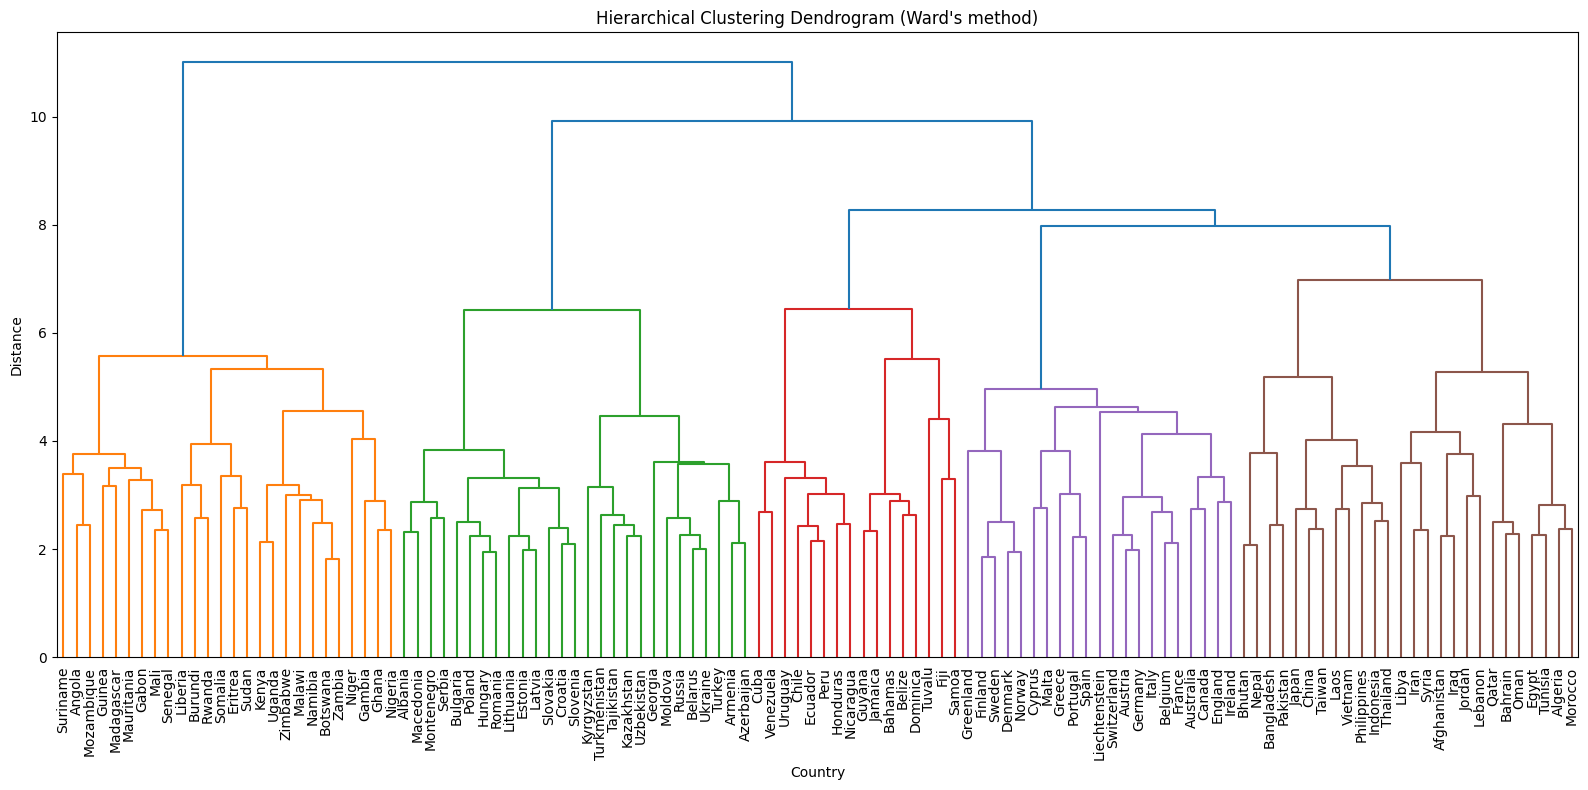

In [28]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

linkage_result = linkage(country_vecs, method='ward')

plt.figure(figsize=(16, 8))
dendrogram(linkage_result, labels=valid_countries, leaf_font_size=10, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Ward's method)")
plt.xlabel("Country")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

## 59. t-SNEによる可視化

ベクトル空間上の国名に関する単語ベクトルをt-SNEで可視化せよ。

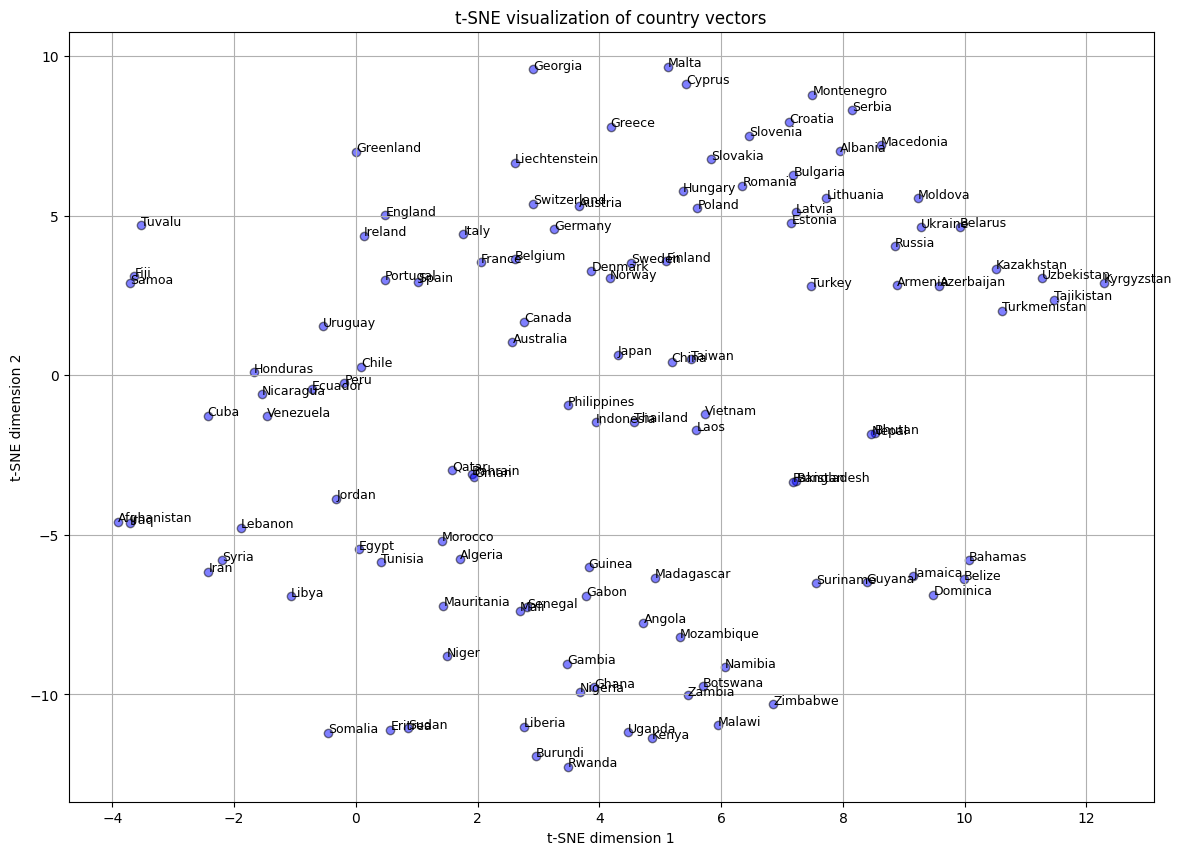

In [29]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42)
reduced_vecs = tsne.fit_transform(np.array(country_vecs))

plt.figure(figsize=(14, 10))
plt.scatter(reduced_vecs[:, 0], reduced_vecs[:, 1], c='blue', edgecolors='k', alpha=0.5)

for i, country in enumerate(valid_countries):
    plt.annotate(country, (reduced_vecs[i, 0], reduced_vecs[i, 1]), fontsize=9)

plt.title("t-SNE visualization of country vectors")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.grid(True)
plt.show()